In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# Our 7 stocks
tickers = ['AAPL', 'TSM', 'XOM', 'PG', 'JPM', 'LLY', 'CAT']

print("Stocks selected:", tickers)

Stocks selected: ['AAPL', 'TSM', 'XOM', 'PG', 'JPM', 'LLY', 'CAT']


In [5]:
# Download 2 years of data
data = yf.download(tickers, start='2023-01-01', end='2025-01-01')['Close']

print(data.head())
print("\nShape:", data.shape)

[*********************100%***********************]  7 of 7 completed

Ticker            AAPL         CAT         JPM         LLY          PG  \
Date                                                                     
2023-01-03  123.096016  226.435379  124.928711  355.829010  139.523834   
2023-01-04  124.365677  228.786179  126.093697  353.986511  140.131363   
2023-01-05  123.046806  227.762436  126.065720  349.911438  138.391556   
2023-01-06  127.574203  235.895477  128.478088  353.830566  141.687042   
2023-01-09  128.095856  233.772156  127.947182  341.049591  139.956467   

Ticker            TSM        XOM  
Date                              
2023-01-03  70.652878  95.434196  
2023-01-04  72.838409  95.711975  
2023-01-05  72.275330  97.853416  
2023-01-06  74.508575  99.036163  
2023-01-09  76.646400  97.190369  

Shape: (502, 7)


In [6]:
# Calculate daily returns
returns = data.pct_change().dropna()

# Mean returns and covariance matrix
mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Mean Daily Returns:")
print(mean_returns)
print("\nCovariance Matrix:")
print(cov_matrix)

Mean Daily Returns:
Ticker
AAPL    0.001498
CAT     0.001054
JPM     0.001347
LLY     0.001700
PG      0.000345
TSM     0.002281
XOM     0.000251
dtype: float64

Covariance Matrix:
Ticker      AAPL       CAT       JPM       LLY        PG       TSM       XOM
Ticker                                                                      
AAPL    0.000181  0.000052  0.000025  0.000040  0.000009  0.000099  0.000007
CAT     0.000052  0.000297  0.000113  0.000023 -0.000004  0.000112  0.000090
JPM     0.000025  0.000113  0.000195  0.000010  0.000004  0.000045  0.000066
LLY     0.000040  0.000023  0.000010  0.000347  0.000036  0.000073 -0.000005
PG      0.000009 -0.000004  0.000004  0.000036  0.000089 -0.000024  0.000008
TSM     0.000099  0.000112  0.000045  0.000073 -0.000024  0.000514  0.000010
XOM     0.000007  0.000090  0.000066 -0.000005  0.000008  0.000010  0.000196


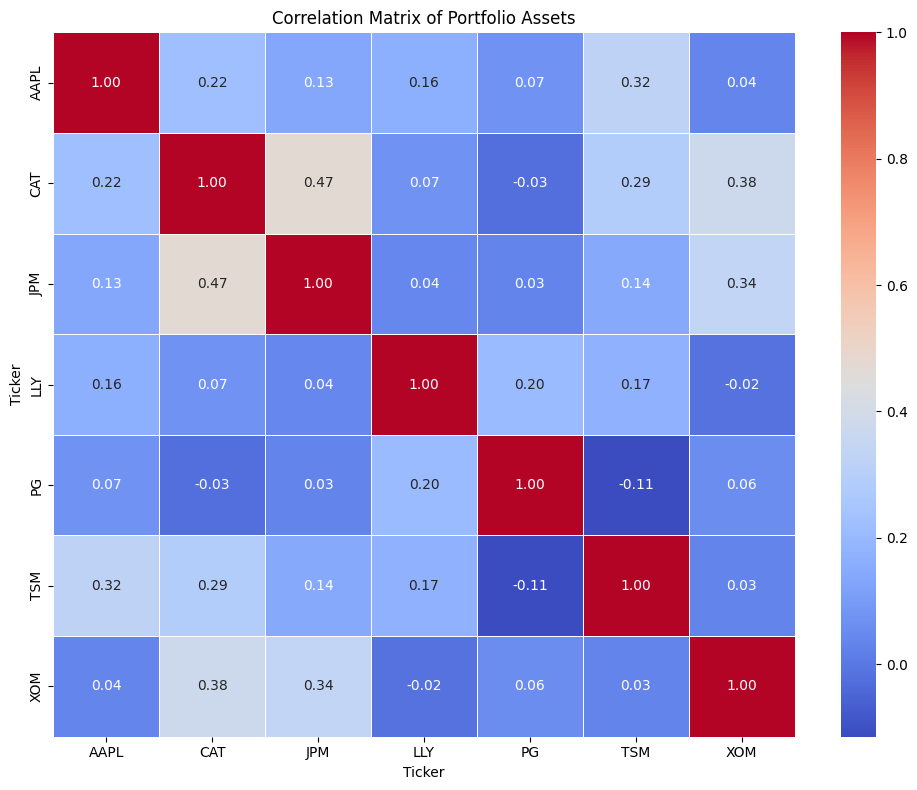

Correlation matrix saved!


In [7]:
# Plot correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Portfolio Assets')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

print("Correlation matrix saved!")

In [8]:
class EfficientFrontier:
    def __init__(self, returns, mean_returns, cov_matrix, risk_free_rate=0.05/252):
        self.returns = returns
        self.mean_returns = mean_returns
        self.cov_matrix = cov_matrix
        self.risk_free_rate = risk_free_rate
        self.num_assets = len(mean_returns)

    def simulate_portfolios(self, num_portfolios=10000):
        results = np.zeros((3, num_portfolios))
        weights_record = []

        for i in range(num_portfolios):
            weights = np.random.random(self.num_assets)
            weights /= np.sum(weights)
            weights_record.append(weights)

            portfolio_return = np.sum(self.mean_returns * weights) * 252
            portfolio_std = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix * 252, weights)))
            sharpe = (portfolio_return - self.risk_free_rate * 252) / portfolio_std

            results[0, i] = portfolio_std
            results[1, i] = portfolio_return
            results[2, i] = sharpe

        return results, weights_record

# Run it
ef = EfficientFrontier(returns, mean_returns, cov_matrix)
results, weights_record = ef.simulate_portfolios(10000)
print("Monte Carlo simulation complete!")
print(f"Simulated {results.shape[1]} portfolios")

Monte Carlo simulation complete!
Simulated 10000 portfolios


In [9]:
# Find optimal portfolio (max Sharpe Ratio)
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[1, max_sharpe_idx]
max_sharpe_risk = results[0, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

# Find minimum variance portfolio
min_var_idx = np.argmin(results[0])
min_var_return = results[1, min_var_idx]
min_var_risk = results[0, min_var_idx]

print("=== OPTIMAL PORTFOLIO (Max Sharpe Ratio) ===")
for ticker, weight in zip(tickers, max_sharpe_weights):
    print(f"{ticker}: {weight*100:.2f}%")

print(f"\nExpected Annual Return: {max_sharpe_return*100:.2f}%")
print(f"Annual Risk (Std Dev): {max_sharpe_risk*100:.2f}%")
print(f"Sharpe Ratio: {results[2, max_sharpe_idx]:.4f}")

=== OPTIMAL PORTFOLIO (Max Sharpe Ratio) ===
AAPL: 21.32%
TSM: 1.66%
XOM: 33.83%
PG: 22.72%
JPM: 3.53%
LLY: 14.81%
CAT: 2.14%

Expected Annual Return: 38.66%
Annual Risk (Std Dev): 14.96%
Sharpe Ratio: 2.2502


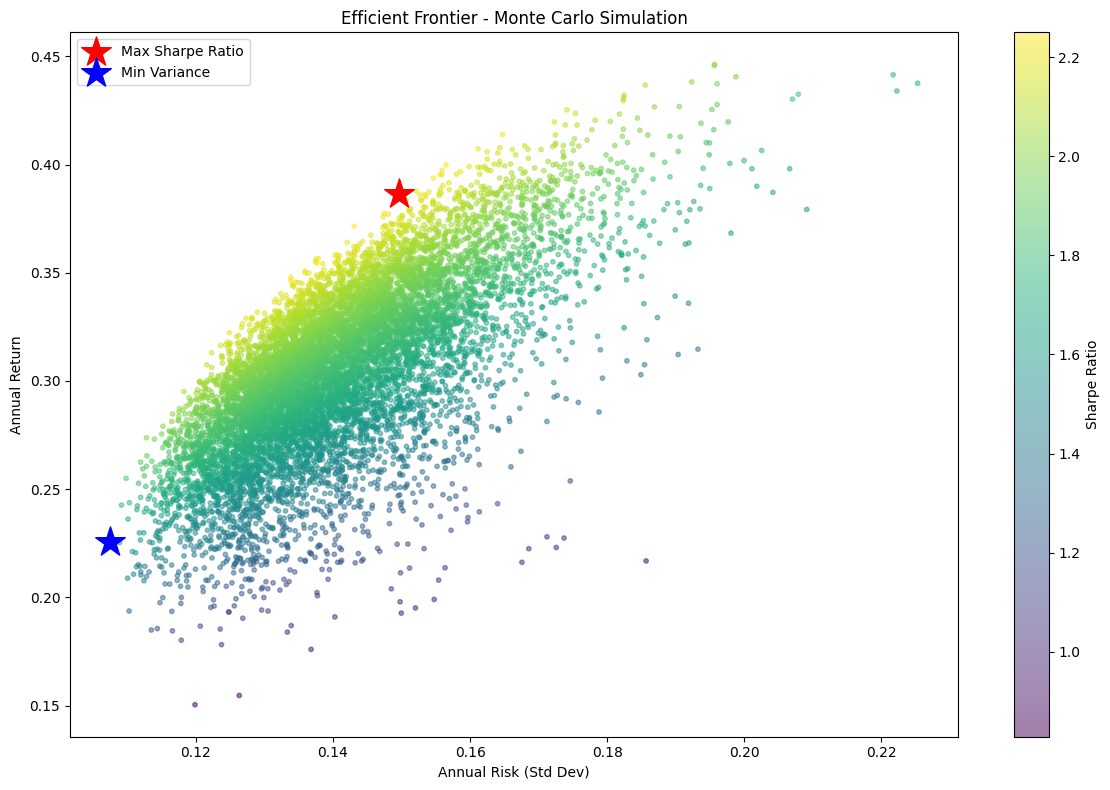

Efficient frontier saved!


In [10]:
# Plot Efficient Frontier
plt.figure(figsize=(12, 8))

# Scatter plot of all simulated portfolios colored by Sharpe Ratio
scatter = plt.scatter(results[0, :], results[1, :], 
                      c=results[2, :], cmap='viridis', 
                      marker='o', s=10, alpha=0.5)
plt.colorbar(scatter, label='Sharpe Ratio')

# Plot max Sharpe Ratio portfolio
plt.scatter(max_sharpe_risk, max_sharpe_return, 
            marker='*', color='red', s=500, label='Max Sharpe Ratio')

# Plot minimum variance portfolio
plt.scatter(min_var_risk, min_var_return, 
            marker='*', color='blue', s=500, label='Min Variance')

plt.title('Efficient Frontier - Monte Carlo Simulation')
plt.xlabel('Annual Risk (Std Dev)')
plt.ylabel('Annual Return')
plt.legend()
plt.tight_layout()
plt.savefig('efficient_frontier.png')
plt.show()

print("Efficient frontier saved!")

In [11]:
pip install scikit-learn

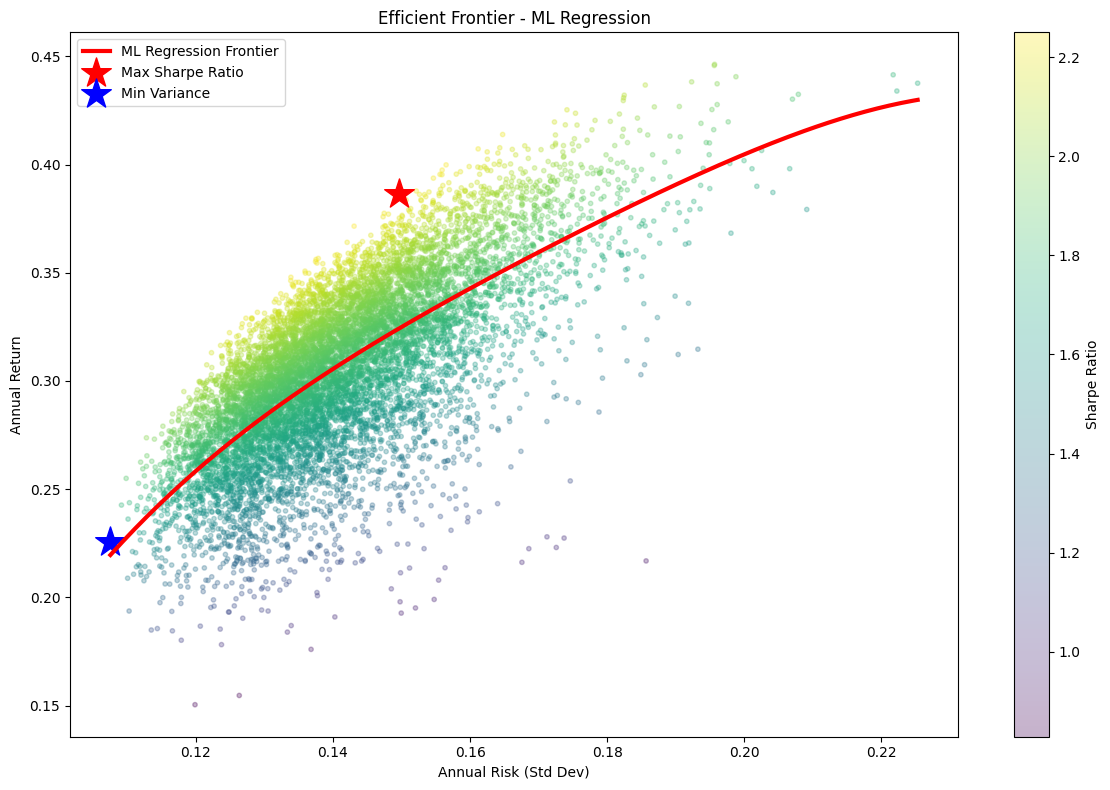

ML Regression frontier saved!


In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Get frontier points
min_var_risk_val = results[0, min_var_idx]
mask = results[0, :] >= min_var_risk_val
frontier_risk = results[0, mask]
frontier_return = results[1, mask]

# Sort by risk
sorted_idx = np.argsort(frontier_risk)
frontier_risk_sorted = frontier_risk[sorted_idx]
frontier_return_sorted = frontier_return[sorted_idx]

# Fit polynomial regression
model = make_pipeline(PolynomialFeatures(degree=4), LinearRegression())
model.fit(frontier_risk_sorted.reshape(-1, 1), frontier_return_sorted)

# Generate smooth curve
x_range = np.linspace(frontier_risk_sorted.min(), frontier_risk_sorted.max(), 200)
y_pred = model.predict(x_range.reshape(-1, 1))

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(results[0, :], results[1, :], c=results[2, :], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.plot(x_range, y_pred, color='red', linewidth=3, label='ML Regression Frontier')
plt.scatter(max_sharpe_risk, max_sharpe_return, marker='*', color='red', s=500, label='Max Sharpe Ratio')
plt.scatter(min_var_risk, min_var_return, marker='*', color='blue', s=500, label='Min Variance')
plt.title('Efficient Frontier - ML Regression')
plt.xlabel('Annual Risk (Std Dev)')
plt.ylabel('Annual Return')
plt.legend()
plt.tight_layout()
plt.savefig('efficient_frontier_ml.png')
plt.show()

print("ML Regression frontier saved!")